<a href="https://colab.research.google.com/github/chandradharvasireddy-19/25BDS0329/blob/main/exp7_25.08.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
df=pd.read_csv("/content/Iris.csv")
print(df.head(3))
print(df.tail(3))

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
147  Iris-virginica  
148  Iris-virginica  
149  Iris-virginica  


In [5]:
df.dtypes

,0
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


In [6]:
print(df.describe())
pd.isna(df).any()

               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


,0
Id,False
SepalLengthCm,False
SepalWidthCm,False
PetalLengthCm,False
PetalWidthCm,False
Species,False


In [9]:
df['SepalWidthCm'].isna().value_counts()


,count
SepalWidthCm,
False,150


In [10]:
SepalWidthCm = df['SepalWidthCm'].loc[df['SepalWidthCm'] != '?']
print(SepalWidthCm)

0      3.5
1      3.0
2      3.2
3      3.1
4      3.6
      ... 
145    3.0
146    2.5
147    3.0
148    3.4
149    3.0
Name: SepalWidthCm, Length: 150, dtype: float64


In [11]:
pmean = SepalWidthCm.astype(int).mean()
print("Mean =",pmean)

Mean = 2.6466666666666665


In [12]:
df['SepalWidthCm'] = df['SepalWidthCm'].replace('?',pmean).astype(int)
df['SepalWidthCm'].head(10)

,SepalWidthCm
0,3
1,3
2,3
3,3
4,3
5,3
6,3
7,3
8,2
9,3


In [13]:
#descriptive statistics
mean = df["SepalLengthCm"].mean()
median =df["SepalLengthCm"].median()
mode = df["SepalLengthCm"].mode()
print(mean , median, mode)

5.843333333333334 5.8 0    5.0
Name: SepalLengthCm, dtype: float64


/tmp/ipykernel_1281/1361624642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Species', ax=axes[0, 0], palette='Set2', edgecolor='black')
/tmp/ipykernel_1281/1361624642.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y='PetalWidthCm', ax=axes[1, 0], palette='Pastel1')


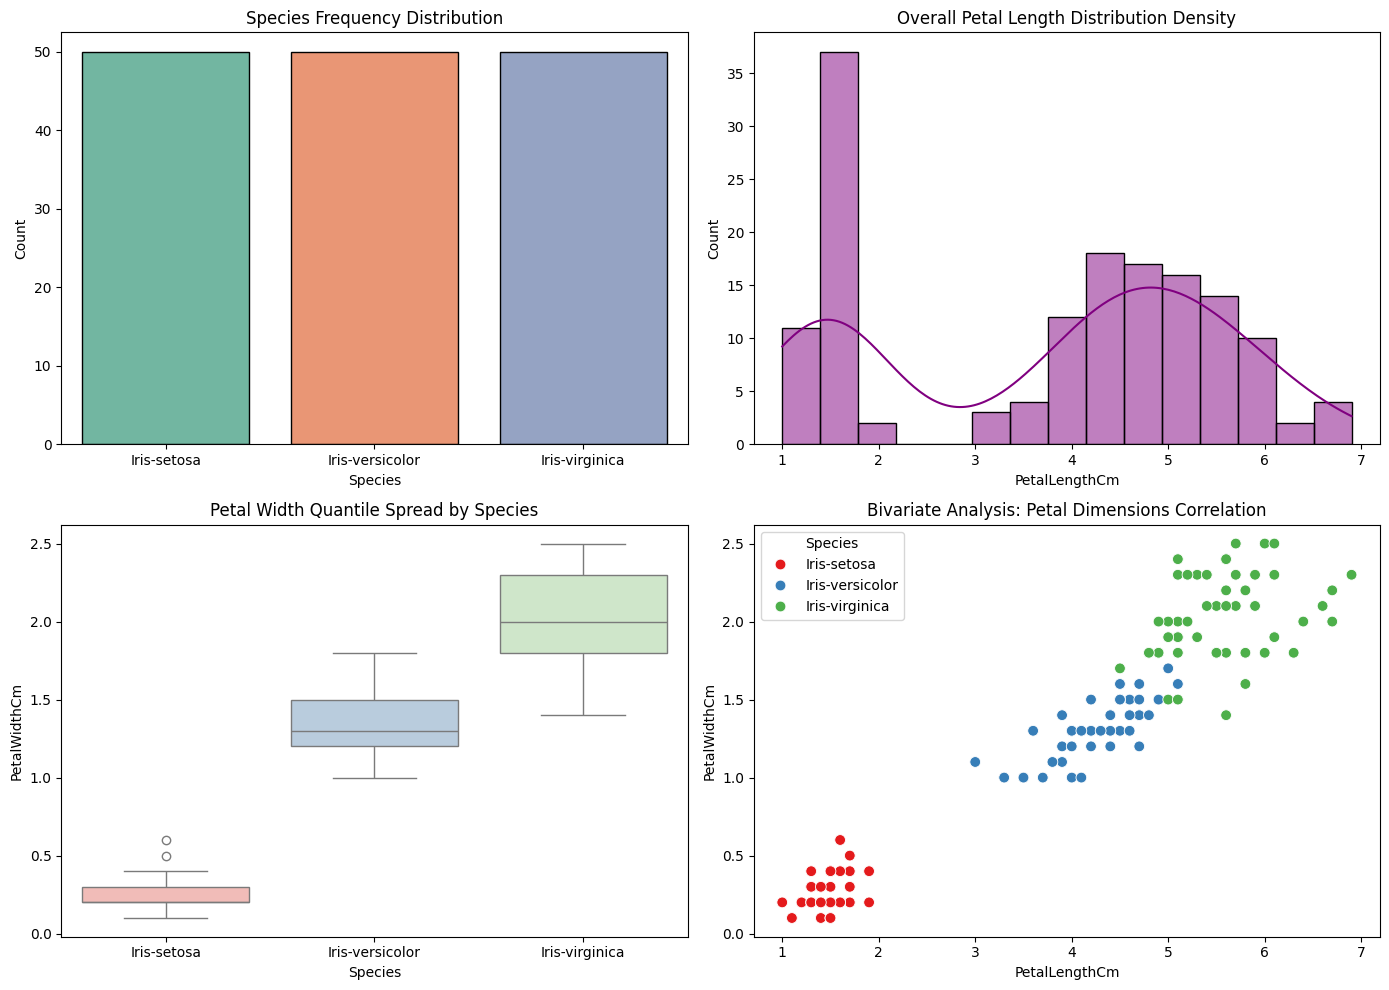

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, x='Species', ax=axes[0, 0], palette='Set2', edgecolor='black')
axes[0, 0].set_title('Species Frequency Distribution')
axes[0, 0].set_ylabel('Count')
sns.histplot(data=df, x='PetalLengthCm', kde=True, ax=axes[0, 1], color='purple', bins=15)
axes[0, 1].set_title('Overall Petal Length Distribution Density')
sns.boxplot(data=df, x='Species', y='PetalWidthCm', ax=axes[1, 0], palette='Pastel1')
axes[1, 0].set_title('Petal Width Quantile Spread by Species')
sns.scatterplot(data=df, x='PetalLengthCm', y='PetalWidthCm', hue='Species', ax=axes[1, 1], palette='Set1', s=60)
axes[1, 1].set_title('Bivariate Analysis: Petal Dimensions Correlation')
plt.tight_layout()
plt.show()

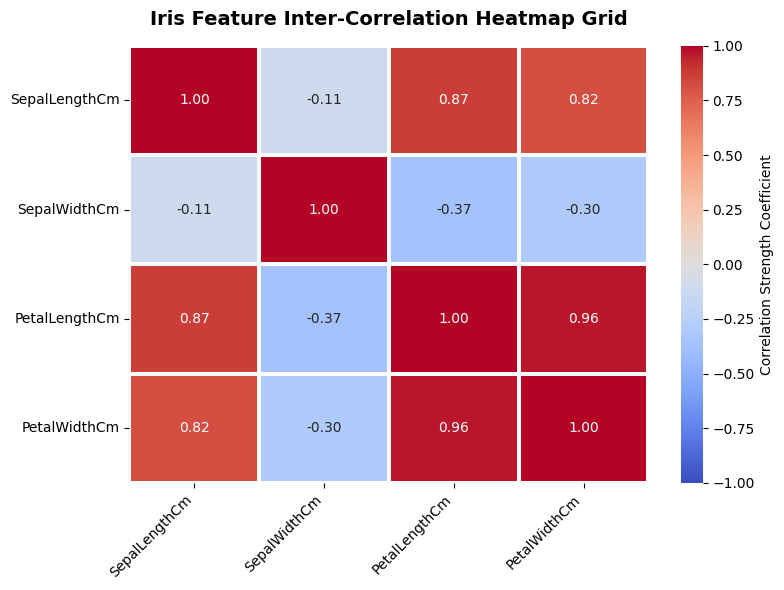

In [24]:
numeric_df = df.drop(columns=['Id', 'Species'])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix,annot=True, cmap='coolwarm',fmt='.2f', linewidths=1.5,vmin=-1,vmax=1,cbar_kws={'label': 'Correlation Strength Coefficient'}
)
plt.title('Iris Feature Inter-Correlation Heatmap Grid', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()